# Initial EDA: Normal Features With Target

This notebook builds one dataframe from the quarterly node files and adds the target variable.

Nodes are banks. Rows are bank-quarter observations. Features are the normal bank-level variables from `src/datasets/nodes`. The target is `systemic_risk_label` from `src/datasets/targets`.

This is only an initial EDA. There are no predictive models, train/test splits, or prediction results.


## Setup

Load packages and find the project root.


In [121]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")

BRAND_GREEN = "#BED62F"
BRAND_GRAY = "#5C666C"
BRAND_PALETTE = [BRAND_GREEN, BRAND_GRAY]

sns.set_theme(style="white", palette=BRAND_PALETTE)
plt.rcParams["axes.edgecolor"] = BRAND_GRAY
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root(start=None):
    """Find the repository root from the current working directory."""
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "requirements.txt").exists():
            return path
    raise FileNotFoundError("Project root not found.")


PROJECT_ROOT = find_project_root()
NODE_DIR = PROJECT_ROOT / "src" / "datasets" / "nodes"
TARGET_DIR = PROJECT_ROOT / "src" / "datasets" / "targets"
TARGET_COL = "systemic_risk_label"

print(f"Project root: {PROJECT_ROOT}")
print(f"Node dir: {NODE_DIR}")
print(f"Target dir: {TARGET_DIR}")


Project root: /Users/rubenmarques/Documents/Repositórios/Thesis
Node dir: /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/nodes
Target dir: /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/targets


## Build Dataset

Each quarter has a node feature file and a target file. The node files identify banks with `index`, so it is renamed to `bank_id` before merging.


In [122]:

def load_quarter_dataset(node_path, target_dir):
    """Load one quarter of node features and merge the target."""
    period = node_path.stem
    year = int(period[:4])
    quarter = int(period[-1])
    target_path = target_dir / f"target_{period}.csv"

    if not target_path.exists():
        raise FileNotFoundError(f"Missing target file: {target_path}")

    nodes = pd.read_csv(node_path)
    targets = pd.read_csv(target_path)

    if "index" not in nodes.columns:
        raise ValueError(f"Expected an index column in {node_path}")

    nodes = nodes.rename(columns={"index": "bank_id"})

    # Validate the merge keys before joining.
    if nodes["bank_id"].duplicated().any():
        raise ValueError(f"Duplicated bank_id values in {node_path}")
    if targets["bank_id"].duplicated().any():
        raise ValueError(f"Duplicated bank_id values in {target_path}")

    merged = nodes.merge(targets, on="bank_id", how="inner", validate="one_to_one")
    merged["year"] = year
    merged["quarter"] = quarter
    merged["period"] = period

    return merged


node_files = sorted(NODE_DIR.glob("*.csv"))
quarter_frames = [load_quarter_dataset(path, TARGET_DIR) for path in node_files]

df = pd.concat(quarter_frames, ignore_index=True)

# Put identifiers first, then features, then target.
id_cols = ["bank_id", "year", "quarter", "period"]
feature_cols_all = [col for col in df.columns if col not in id_cols + [TARGET_COL]]
df = df[id_cols + feature_cols_all + [TARGET_COL]]

print(f"Quarter files loaded: {len(node_files)}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()


Quarter files loaded: 32
Rows: 145,536
Columns: 78


,bank_id,year,quarter,period,Total_assets,Total_liabilities,Equity,Liquid_assets,Deposits_and_short-term_funding,Long-term_funding,Net_income,Interbank_assets,Interbank_liabilities,Return_on_average_equity_(ROAE),Wholesale_funding,Growth_in_total_assets,Impaired_loans_/_Gross_customer_loans_&_advances,Loan_loss_reserves_/_Impaired_loans,Customer_loans_&_advances_/_Total_assets,Net_charge_offs_(NCOs)_/_Average_gross_customer_loans_&_advances,Unreserved_impaired_loans_/_Total_equity,Total_Common_Equity_/_Core_Tier_1,Total_Capital,Exchange_rate_from_original_currency,Gross_loans_&_advances_to_customers,Wholesale_funding_/_Total_funding_excluding_derivatives,Loans_&_advances_to_customers_/_Total_deposits_&_other_interest-bearing_liabilities,Financial_assets:_Available_for_sale_(AFS),Total_Earning_Assets,Unadjusted_leverage_ratio_(computed),Tier_1_Ratio,Interest_Expense,Tier_1_Capital,Long-term_borrowings_and_debt_securities_at_historical_cost_>_1_year,Impaired_/_Non-performing_loans_to_customers,Other_reserves,Interest_expense_on_customer_deposits,Interest_expense_/_average_interest_bearing_liabilities,Interest_expense_on_customer_deposits_/_Average_customer_deposits,Total_capital_adequacy_ratio,Interest_income_/_average_interest_earning_assets,Interest_income_on_bank_loans_(including_central_banks),Other_administrative_expenses,Interest_income_on_loans_/_Average_gross_customer_loans_&_advances,Other_interest_income,Effective_tax_rate,Total_net_trading_income_(losses)_and_fair_value_(FV)_gains_(losses),Savings_deposits,Total_equity_/_Risk-weighted_assets_(RWAs),Growth_in_net_customer_loans_&_advances,Net_loans_&_advances_to_customers,Net_gains_(losses)_on_other_securities_(including_FV_through_OCI),Customer_deposits_/_Total_funding_excluding_derivatives,Operating_revenue_after_impairments,Net_interest_income_(expenses)_/_Average_total_assets,Liquid_assets_(including_available_for_sale_&_held_to_maturity)_/_Total_assets,Impaired_loans_+_foreclosed_assets_/_gross_customer_loans_&_advances_+_foreclosed_assets,Financial_assets:_Held_to_maturity_(HTM),Risk_weighted_asset_intensity_(RWA_/_Total_Assets),Minimum_risk_assets,Gross_loans_&_advances_to_customers_/_Customer_deposits,Number_of_employees,Net_interest_margin_(average_interest_earning_assets),Loans_&_advances_to_customers_/_Deposits_&_short-term_funding,Profit_attributable_to_group_equity_holders,Interest_income_on_customer_loans_&_advances,Total_other_earning_assets,Total_equity_/_Total_liabilities_excluding_hybrid_capital_and_subordinated_liabilities,Capital_funds_/_Total_assets,Growth_in_gross_customer_loans_&advances,Capital_funds_/_Net_loans_&_advances_to_customers,Time_deposits,Non-interest_income_/_Operating_revenues,Net_interest_margin_(interest_earning_assets),rank_next_quarter,srisk_ratio,srisk_value,systemic_risk_label
0,0,2016,1,2016Q1,"2,015,718,000.0000","1,817,839,000.0000","197,879,000.0000","995,459,000.0000","1,532,137,000.0000","90,858,000.0000","4,197,000.0000","284,783,000.0000","152,442,000.0000",8.5288,"294,023,000.0000",5.2782,1.4059,106.2353,36.9058,0.0647,-0.3345,"170,985,000.0000","178,517,000.0000",1.0000,"755,195,000.0000",17.5231,42.9107,"232,975,000.0000","1,590,466,000.0000",6.8661,13.2530,"1,131,000.0000","171,229,000.0000","82,293,000.0000","10,617,000.0000","2,416,000.0000","396,000.0000",0.2673,0.1229,13.8171,2.6047,"428,000.0000","5,904,000.0000",3.3928,"1,483,000.0000",27.7625,"2,478,000.0000","786,490,000.0000",15.3157,2.7887,"743,916,000.0000","51,000.0000",79.2035,"17,636,000.0000",1.8195,51.7627,1.4942,"47,932,000.0000",64.0962,"285,569,000.0000",56.8255,"182,243.0000",2.8036,48.5541,"4,196,000.0000","6,318,000.0000","846,550,000.0000",10.9369,10.2417,2.8120,27.7510,"68,508,000.0000",52.0337,2.7303,1.0000,9.6800,"64,677.6000",215
1,1,2016,1,2016Q1,"1,653,947,000.0000","1,445,797,000.0000","208,150,000.0000","520,240,000.0000","1,363,841,000.0000","25,119,000.0000","3,712,000.0000","47,474,000.0000","50,420,000.0000",7.2489,"112,025,000.00

## Basic Structure

Check the size, columns, data types, and period coverage.


In [123]:

dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="n_columns")
)

dtype_summary


,dtype,n_columns
0,float64,73
1,int64,4
2,str,1


In [124]:

period_summary = (
    df.groupby(["year", "quarter", "period"])
    .agg(
        rows=(TARGET_COL, "size"),
        banks=("bank_id", "nunique"),
        target_mean=(TARGET_COL, "mean"),
        target_median=(TARGET_COL, "median"),
        target_max=(TARGET_COL, "max"),
    )
    .reset_index()
)

period_summary.head(12)


,year,quarter,period,rows,banks,target_mean,target_median,target_max
0,2016,1,2016Q1,4548,4548,1.2390,1.0000,215
1,2016,2,2016Q2,4548,4548,1.1401,1.0000,112
2,2016,3,2016Q3,4548,4548,1.1016,1.0000,65
3,2016,4,2016Q4,4548,4548,1.0807,1.0000,28
4,2017,1,2017Q1,4548,4548,1.0833,1.0000,33
5,2017,2,2017Q2,4548,4548,1.0739,1.0000,41
6,2017,3,2017Q3,4548,4548,1.0734,1.0000,34
7,2017,4,2017Q4,4548,4548,1.0772,1.0000,31
8,2018,1,2018Q1,4548,4548,1.1082,1.0000,40
9,2018,2,2018Q2,4548,4548,1.0937,1.0000,37


In [125]:

period_summary.tail(12)


,year,quarter,period,rows,banks,target_mean,target_median,target_max
20,2021,1,2021Q1,4548,4548,1.2263,1.0000,90
21,2021,2,2021Q2,4548,4548,1.2137,1.0000,101
22,2021,3,2021Q3,4548,4548,1.1992,1.0000,81
23,2021,4,2021Q4,4548,4548,1.1957,1.0000,90
24,2022,1,2022Q1,4548,4548,1.2386,1.0000,104
25,2022,2,2022Q2,4548,4548,1.2559,1.0000,106
26,2022,3,2022Q3,4548,4548,1.2568,1.0000,113
27,2022,4,2022Q4,4548,4548,1.1981,1.0000,77
28,2023,1,2023Q1,4548,4548,1.1799,1.0000,72
29,2023,2,2023Q2,4548,4548,1.1544,1.0000,60


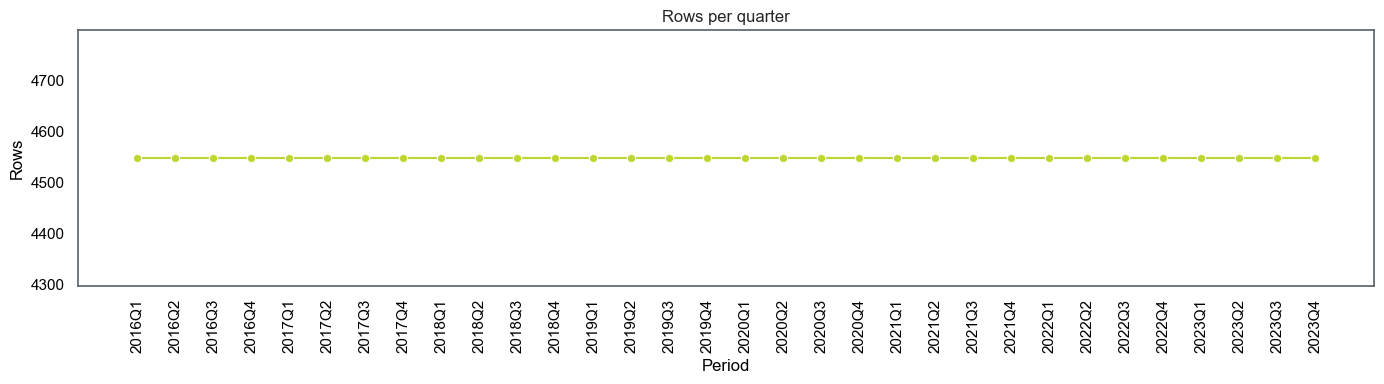

In [126]:

plt.figure(figsize=(14, 4))
sns.lineplot(data=period_summary, x="period", y="rows", marker="o", color=BRAND_GREEN)
plt.xticks(rotation=90)
plt.title("Rows per quarter")
plt.xlabel("Period")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


## Data Quality

Check missing values, duplicate bank-quarter rows, and target validity.


In [127]:

missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_rate=lambda x: x["missing_count"] / len(df))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

missing_summary.head(30)


,missing_count,missing_rate
srisk_ratio,137363,0.9438
srisk_value,137363,0.9438
rank_next_quarter,4548,0.0312


In [128]:

duplicate_count = df.duplicated(subset=["bank_id", "year", "quarter"]).sum()

print(f"Duplicated bank-quarter rows: {duplicate_count:,}")
print(f"Target missing values: {df[TARGET_COL].isna().sum():,}")
print(f"Negative target values: {(df[TARGET_COL] < 0).sum():,}")
print(f"Zero target values: {(df[TARGET_COL] == 0).sum():,}")


Duplicated bank-quarter rows: 0
Target missing values: 0
Negative target values: 0
Zero target values: 0


In [129]:

# Missing values by year helps detect periods with weaker coverage.
missing_by_year = (
    df.assign(row_missing=df[feature_cols_all].isna().sum(axis=1))
    .groupby("year")
    .agg(
        rows=("bank_id", "size"),
        avg_missing_features=("row_missing", "mean"),
        max_missing_features=("row_missing", "max"),
    )
)

missing_by_year


,rows,avg_missing_features,max_missing_features
year,,,
2016,18192,1.8819,2
2017,18192,1.8792,2
2018,18192,1.8784,2
2019,18192,1.8770,2
2020,18192,1.8743,2
2021,18192,1.8723,2
2022,18192,1.8708,2
2023,18192,2.2176,3


## Target Distribution

Inspect the target on the raw scale and log scale. The log view is useful when a few banks have much higher values.


In [130]:

target_summary = df[TARGET_COL].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

target_summary.to_frame("value")


,value
count,"145,536.0000"
mean,1.1413
std,2.0506
min,1.0000
1%,1.0000
5%,1.0000
25%,1.0000
50%,1.0000
75%,1.0000
90%,1.0000


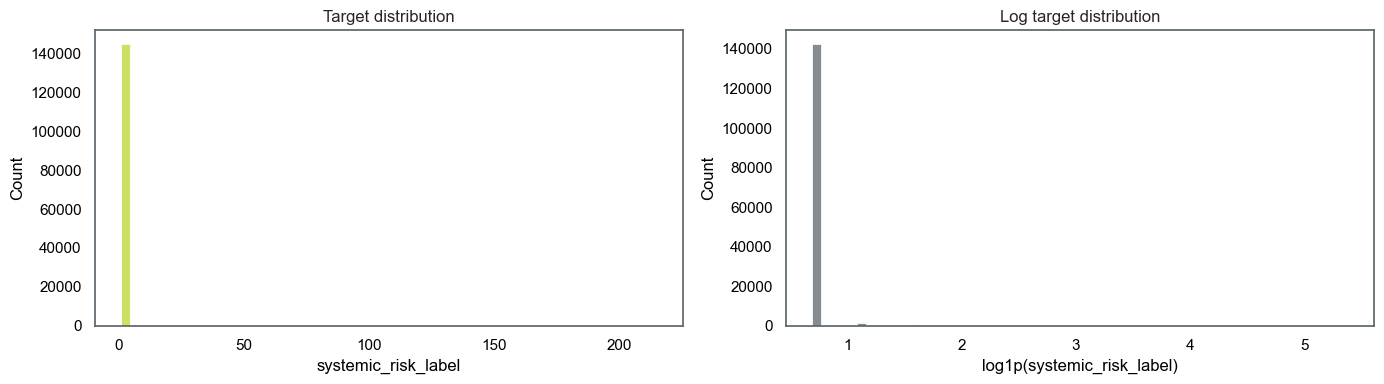

In [131]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[TARGET_COL], bins=60, ax=axes[0], color=BRAND_GREEN)
axes[0].set_title("Target distribution")
axes[0].set_xlabel(TARGET_COL)

sns.histplot(np.log1p(df[TARGET_COL]), bins=60, ax=axes[1], color=BRAND_GRAY)
axes[1].set_title("Log target distribution")
axes[1].set_xlabel(f"log1p({TARGET_COL})")

plt.tight_layout()
plt.show()


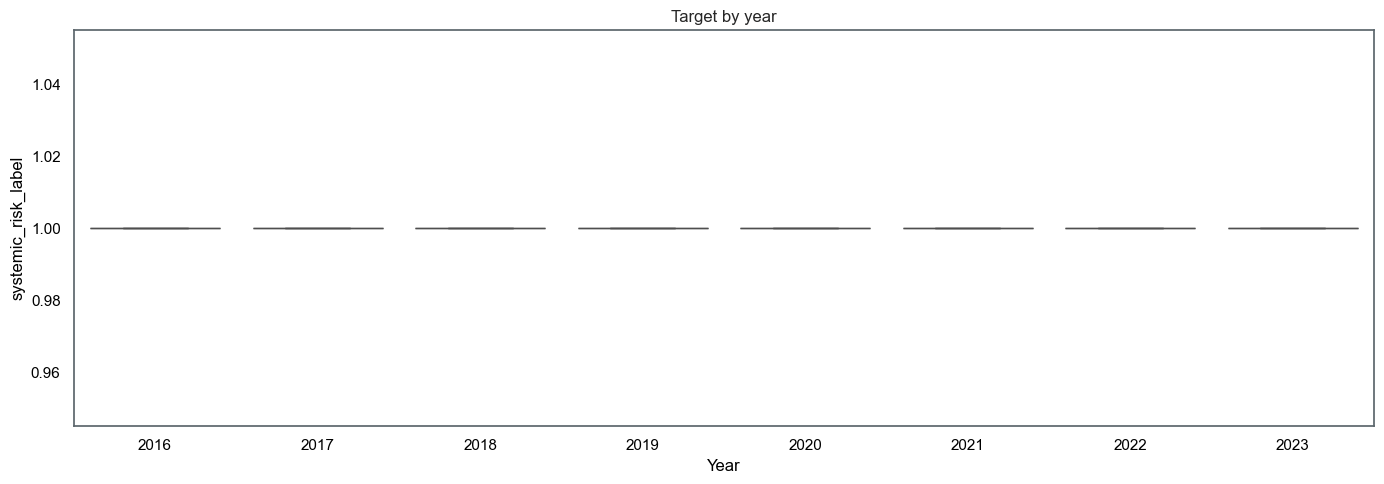

In [132]:

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="year", y=TARGET_COL, showfliers=False, color=BRAND_GREEN)
plt.title("Target by year")
plt.xlabel("Year")
plt.ylabel(TARGET_COL)
plt.tight_layout()
plt.show()


In [133]:

# Highest target observations.
(
    df[["bank_id", "year", "quarter", "period", TARGET_COL]]
    .sort_values(TARGET_COL, ascending=False)
    .head(20)
)


,bank_id,year,quarter,period,systemic_risk_label
0,0,2016,1,2016Q1,215
118253,5,2022,3,2022Q3,113
4548,0,2016,2,2016Q2,112
118248,0,2022,3,2022Q3,107
113705,5,2022,2,2022Q2,106
109157,5,2022,1,2022Q1,104
113700,0,2022,2,2022Q2,104
95513,5,2021,2,2021Q2,101
2,2,2016,1,2016Q1,95
8,8,2016,1,2016Q1,95


## Target Distribution Without Ones

Most rows have `systemic_risk_label = 1`. This view removes those rows so the higher-risk tail is easier to inspect.


In [134]:

risk_tail_df = df[df[TARGET_COL] > 1].copy()
risk_tail_rate = len(risk_tail_df) / len(df)

print(f"Rows with target > 1: {len(risk_tail_df):,}")
print(f"Share of dataset: {risk_tail_rate:.2%}")

mean_comparison = pd.DataFrame({
    "sample": ["all_rows", "target_greater_than_1"],
    "rows": [len(df), len(risk_tail_df)],
    "mean_target": [df[TARGET_COL].mean(), risk_tail_df[TARGET_COL].mean()],
    "median_target": [df[TARGET_COL].median(), risk_tail_df[TARGET_COL].median()],
})

display(mean_comparison)

risk_tail_df[TARGET_COL].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("value")


Rows with target > 1: 3,349
Share of dataset: 2.30%


,sample,rows,mean_target,median_target
0,all_rows,145536,1.1413,1.0000
1,target_greater_than_1,3349,7.1424,3.0000


,value
count,"3,349.0000"
mean,7.1424
std,12.0797
min,2.0000
25%,2.0000
50%,3.0000
75%,6.0000
90%,16.0000
95%,28.0000
99%,61.0000


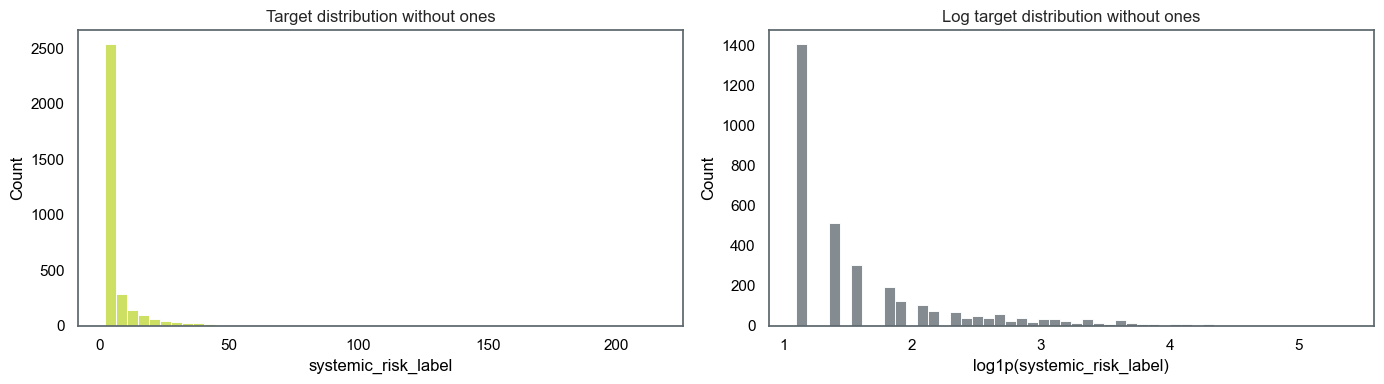

In [135]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(risk_tail_df[TARGET_COL], bins=50, ax=axes[0], color=BRAND_GREEN)
axes[0].set_title("Target distribution without ones")
axes[0].set_xlabel(TARGET_COL)

sns.histplot(np.log1p(risk_tail_df[TARGET_COL]), bins=50, ax=axes[1], color=BRAND_GRAY)
axes[1].set_title("Log target distribution without ones")
axes[1].set_xlabel(f"log1p({TARGET_COL})")

plt.tight_layout()
plt.show()


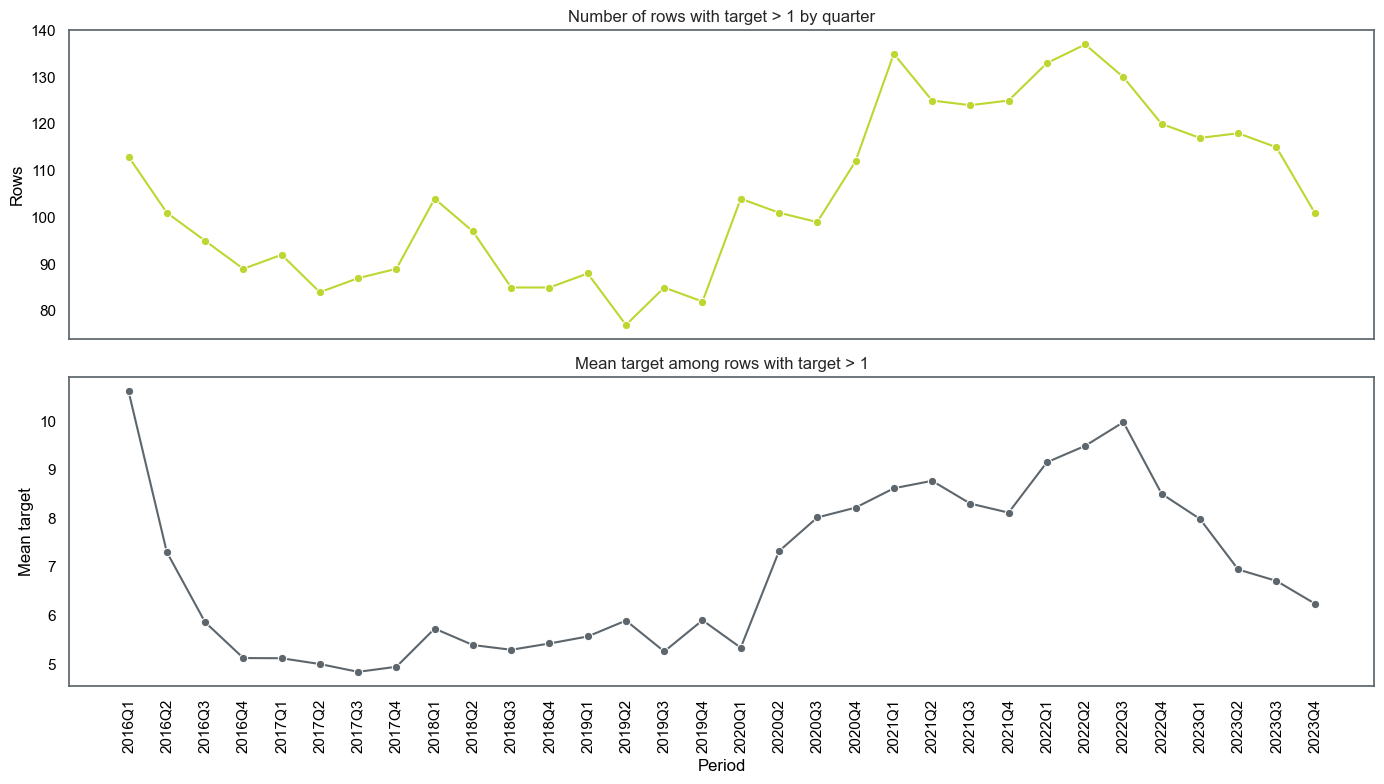

In [136]:

risk_tail_period = (
    risk_tail_df.groupby(["year", "quarter", "period"])
    .agg(
        tail_rows=(TARGET_COL, "size"),
        tail_mean=(TARGET_COL, "mean"),
        tail_max=(TARGET_COL, "max"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.lineplot(data=risk_tail_period, x="period", y="tail_rows", marker="o", ax=axes[0], color=BRAND_GREEN)
axes[0].set_title("Number of rows with target > 1 by quarter")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")

sns.lineplot(data=risk_tail_period, x="period", y="tail_mean", marker="o", ax=axes[1], color=BRAND_GRAY)
axes[1].set_title("Mean target among rows with target > 1")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Mean target")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


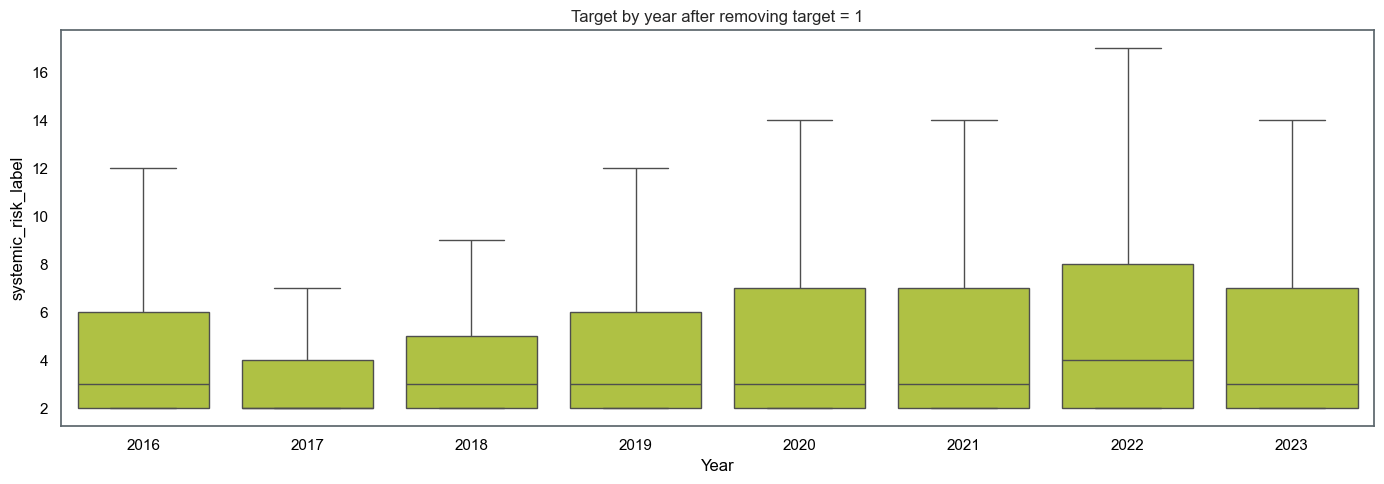

In [137]:

plt.figure(figsize=(14, 5))
sns.boxplot(data=risk_tail_df, x="year", y=TARGET_COL, showfliers=False, color=BRAND_GREEN)
plt.title("Target by year after removing target = 1")
plt.xlabel("Year")
plt.ylabel(TARGET_COL)
plt.tight_layout()
plt.show()


## Target Over Time

Look at how the target changes by quarter. This helps identify periods with higher systemic risk levels.


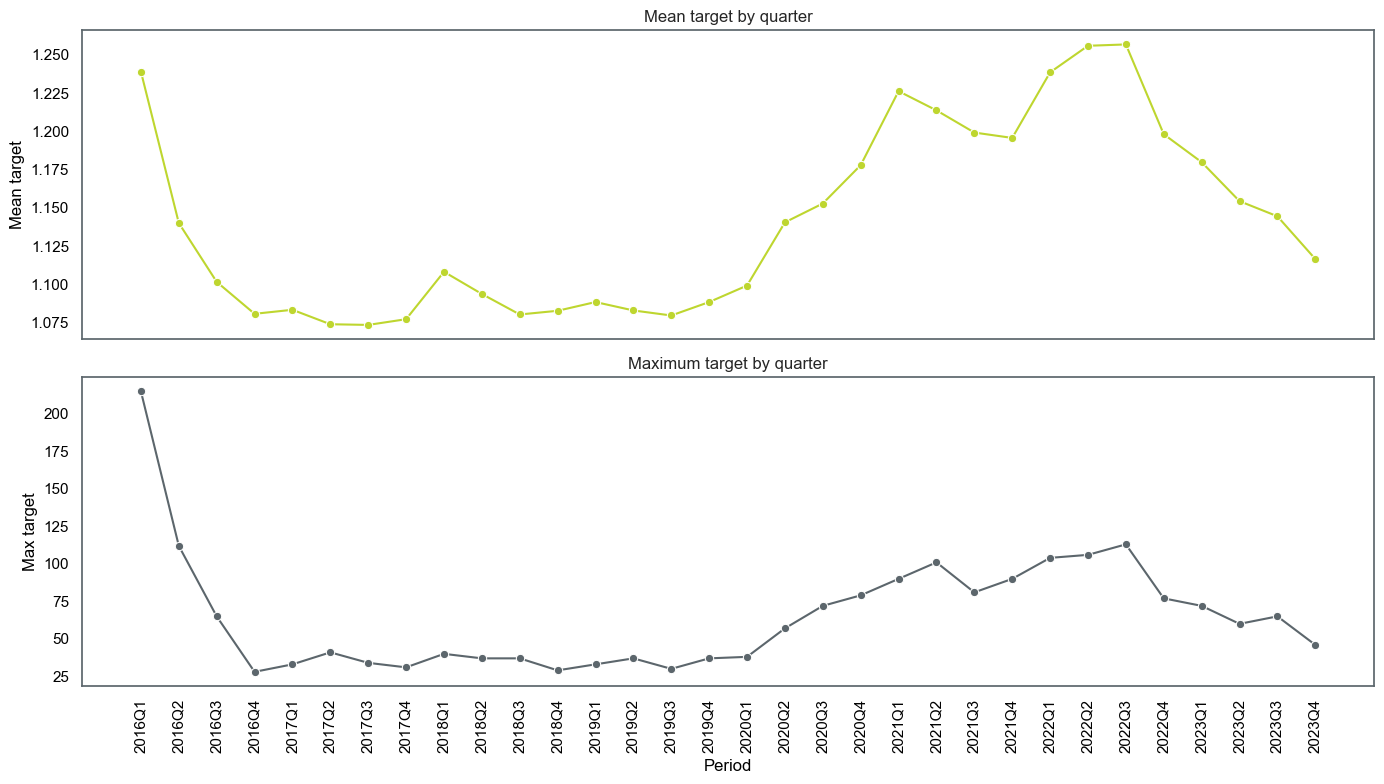

In [138]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.lineplot(data=period_summary, x="period", y="target_mean", marker="o", ax=axes[0], color=BRAND_GREEN)
axes[0].set_title("Mean target by quarter")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean target")

sns.lineplot(data=period_summary, x="period", y="target_max", marker="o", ax=axes[1], color=BRAND_GRAY)
axes[1].set_title("Maximum target by quarter")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Max target")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


In [139]:

# Average target by bank across the full sample.
bank_target_summary = (
    df.groupby("bank_id")
    .agg(
        periods=(TARGET_COL, "size"),
        mean_target=(TARGET_COL, "mean"),
        median_target=(TARGET_COL, "median"),
        max_target=(TARGET_COL, "max"),
    )
    .sort_values("mean_target", ascending=False)
)

bank_target_summary.head(20)


,periods,mean_target,median_target,max_target
bank_id,,,,
0,32,60.3125,49.0000,215
5,32,52.9688,41.0000,113
17,32,40.1250,34.5000,76
8,32,33.5000,28.0000,95
4,32,32.2500,27.5000,62
6,32,26.8125,23.5000,64
2,32,26.2812,19.0000,95
4547,32,26.2500,22.5000,58
7,32,22.7812,20.5000,47


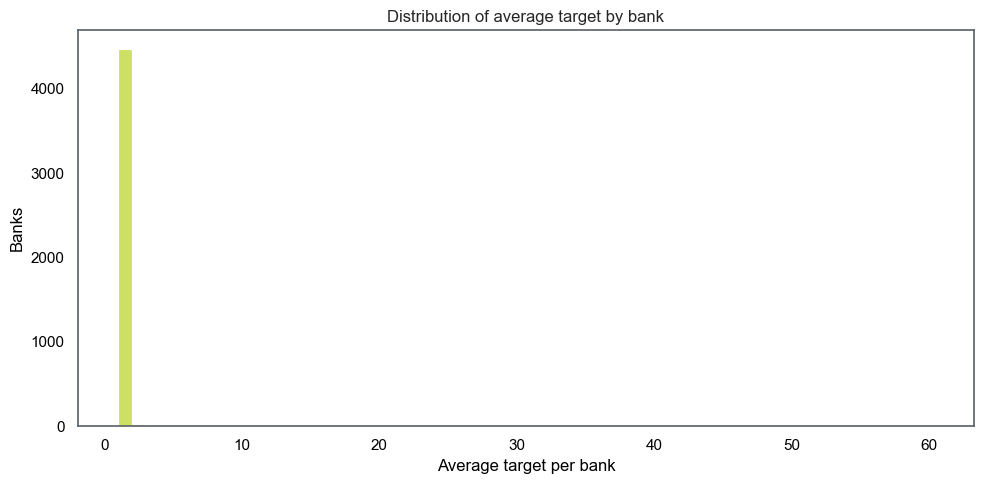

In [140]:

plt.figure(figsize=(10, 5))
sns.histplot(bank_target_summary["mean_target"], bins=60, color=BRAND_GREEN)
plt.title("Distribution of average target by bank")
plt.xlabel("Average target per bank")
plt.ylabel("Banks")
plt.tight_layout()
plt.show()


## Feature Groups

The dataset keeps all node columns. `rank_next_quarter`, `srisk_ratio`, and `srisk_value` are separated because they may contain future or target-related information.


In [141]:

leakage_like_cols = [
    col for col in ["rank_next_quarter", "srisk_ratio", "srisk_value"]
    if col in df.columns
]

normal_feature_cols = [
    col for col in feature_cols_all
    if col not in leakage_like_cols
]

print(f"All node feature columns: {len(feature_cols_all)}")
print(f"Potential leakage columns: {leakage_like_cols}")
print(f"Feature columns used for EDA below: {len(normal_feature_cols)}")


All node feature columns: 73
Potential leakage columns: ['rank_next_quarter', 'srisk_ratio', 'srisk_value']
Feature columns used for EDA below: 70


In [142]:

feature_summary = (
    df[normal_feature_cols]
    .describe()
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .sort_values("std", ascending=False)
)

feature_summary.head(20)


,mean,std,min,25%,50%,75%,max
Total_assets,"8,068,117.7951","76,422,000.3878",0.0000,"113,979.2500","251,828.5000","656,045.5000","3,476,711,000.0000"
Total_liabilities,"7,341,639.9794","69,794,852.1086",0.0000,"99,905.5000","223,160.0000","585,289.2500","3,177,537,000.0000"
Total_Earning_Assets,"6,948,831.9709","64,051,423.2632",0.0000,"107,076.7500","237,198.5000","607,361.2500","2,703,288,000.0000"
Deposits_and_short-term_funding,"6,077,929.1702","59,410,087.5472",0.0000,"97,027.2500","216,164.0000","567,689.0000","2,797,300,000.0000"
Gross_loans_&_advances_to_customers,"4,336,286.6833","35,075,352.4204",0.0000,"64,075.0000","155,426.0000","432,328.5000","1,311,086,000.0000"
Net_loans_&_advances_to_customers,"4,271,168.3228","34,591,605.9583",0.0000,"63,356.0000","153,703.0000","428,567.7500","1,288,751,000.0000"
Savings_deposits,"2,242,271.3120","31,288,699.9568",0.0000,"22,867.7500","57,026.5000","196,284.2500","1,634,859,000.0000"
Total_other_earning_assets,"2,677,663.6482","30,888,588.0412",0.0000,"31,424.7500","70,198.0000","177,240.0000","1,486,441,000.0000"
Liquid_assets,"2,603,836.7950","30,874,171.1505",0.0000,"30,277.0000","68,703.5000","177,554.2500","1,736,077,000.0000"
Wholesale_funding,"1,323,394.1748","14,076,719.2872",0.0000,0.0000,"4,000.0000","23,500.0000","471,403,643.8000"


In [143]:

# Columns with many missing values may need careful imputation or removal.
feature_missing = (
    df[normal_feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_rate")
)

feature_missing.head(20)


,missing_rate
Total_assets,0.0000
Total_equity_/_Risk-weighted_assets_(RWAs),0.0000
Net_interest_income_(expenses)_/_Average_total_assets,0.0000
Operating_revenue_after_impairments,0.0000
Customer_deposits_/_Total_funding_excluding_derivatives,0.0000
Net_gains_(losses)_on_other_securities_(including_FV_through_OCI),0.0000
Net_loans_&_advances_to_customers,0.0000
Growth_in_net_customer_loans_&_advances,0.0000
Savings_deposits,0.0000
Impaired_loans_+_foreclosed_assets_/_gross_customer_loans_&_advances_+_foreclosed_assets,0.0000


## Feature Distributions

Inspect a small set of important balance-sheet variables. The raw scales can be very wide, so log views are useful for positive-valued columns.


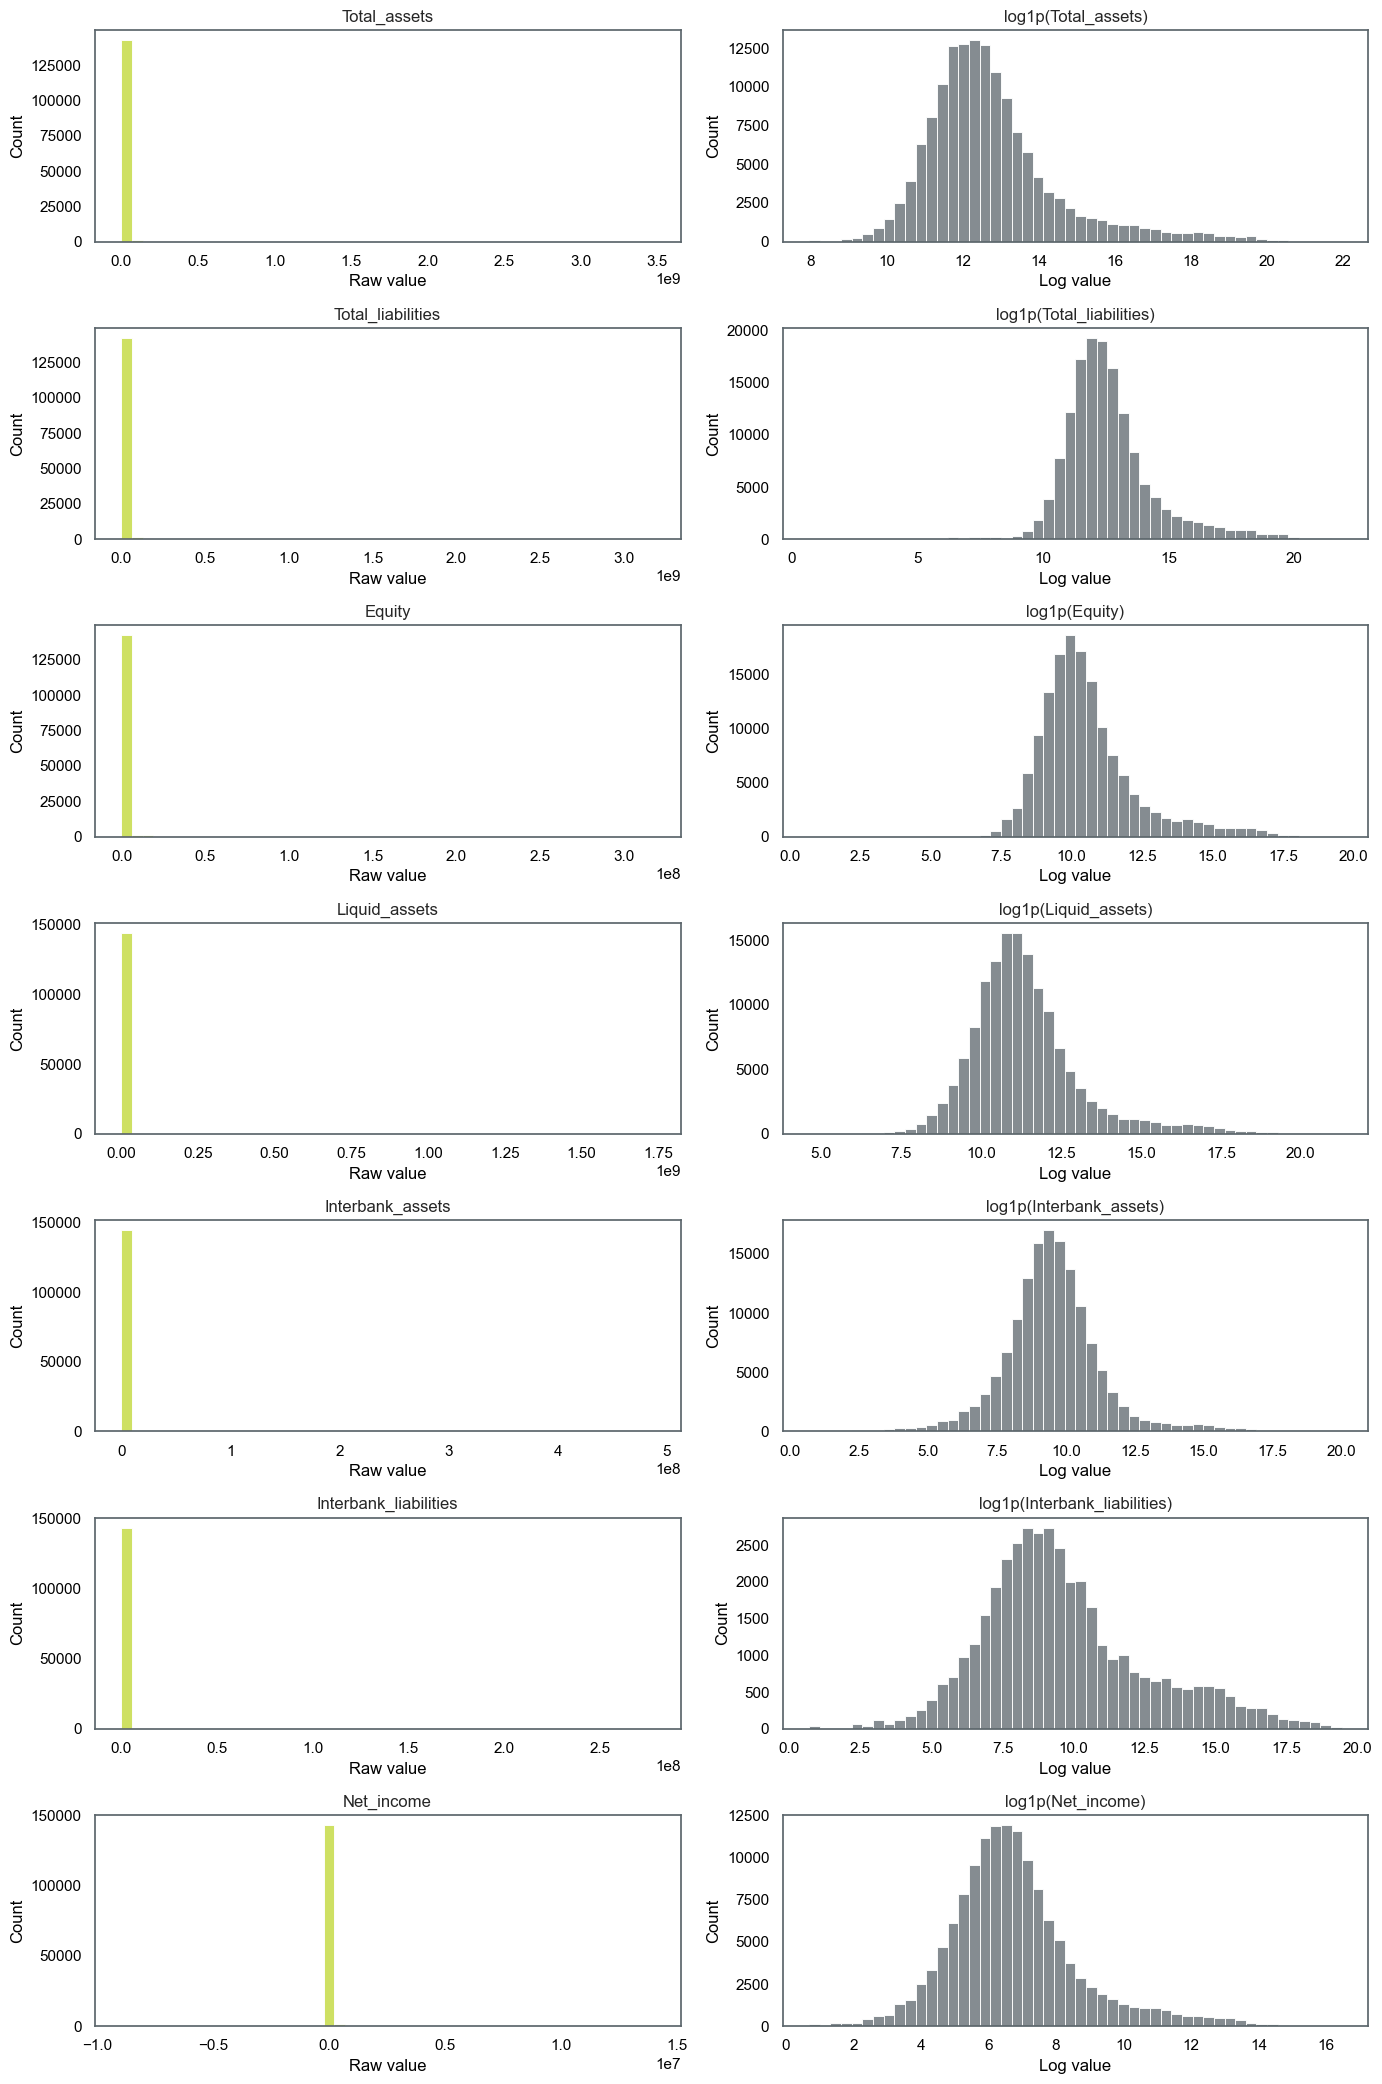

In [144]:

selected_features = [
    col for col in [
        "Total_assets",
        "Total_liabilities",
        "Equity",
        "Liquid_assets",
        "Interbank_assets",
        "Interbank_liabilities",
        "Net_income",
    ]
    if col in df.columns
]

fig, axes = plt.subplots(len(selected_features), 2, figsize=(14, 3 * len(selected_features)))

for i, col in enumerate(selected_features):
    sns.histplot(df[col].dropna(), bins=50, ax=axes[i, 0], color=BRAND_GREEN)
    axes[i, 0].set_title(col)
    axes[i, 0].set_xlabel("Raw value")

    positive_values = df.loc[df[col] > 0, col].dropna()
    sns.histplot(np.log1p(positive_values), bins=50, ax=axes[i, 1], color=BRAND_GRAY)
    axes[i, 1].set_title(f"log1p({col})")
    axes[i, 1].set_xlabel("Log value")

plt.tight_layout()
plt.show()


## Feature Relationship With Target




In [145]:

correlations = (
    df[normal_feature_cols + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

correlations.head(25).to_frame("corr_with_target")


,corr_with_target
Interbank_liabilities,0.8939
Interbank_assets,0.8103
Wholesale_funding,0.7817
Liquid_assets,0.7722
Total_other_earning_assets,0.7466
Total_liabilities,0.7349
Total_assets,0.7281
Total_Earning_Assets,0.7165
Deposits_and_short-term_funding,0.6904
Gross_loans_&_advances_to_customers,0.6604


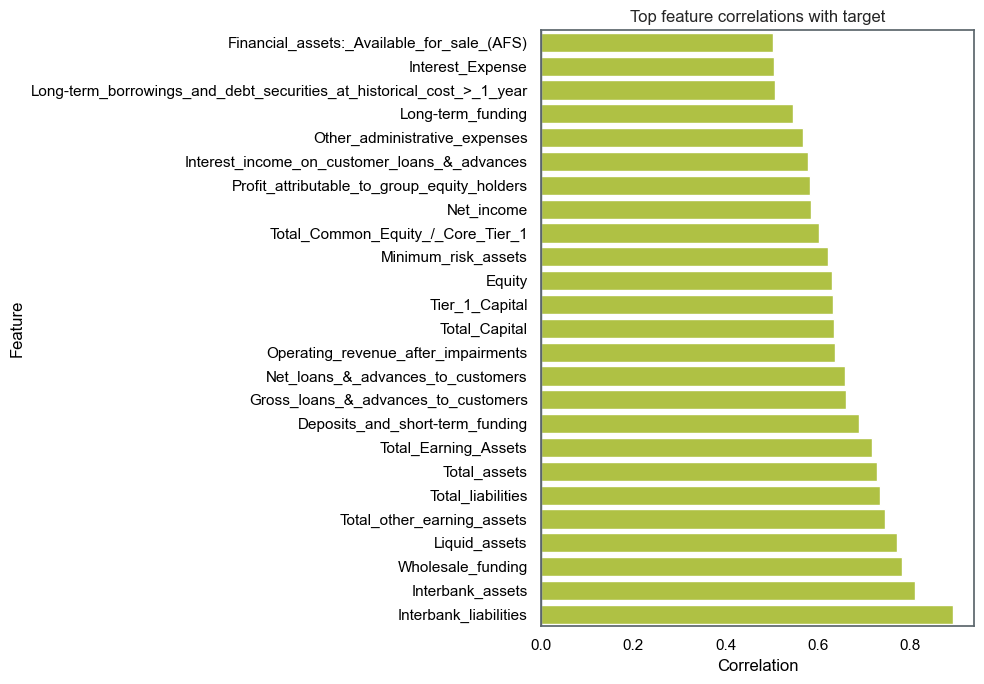

In [146]:

plt.figure(figsize=(10, 7))
top_corr = correlations.head(25).sort_values()
sns.barplot(x=top_corr.values, y=top_corr.index, color=BRAND_GREEN)
plt.axvline(0, color=BRAND_GRAY, linewidth=1)
plt.title("Top feature correlations with target")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [147]:

# Compare target to SRISK columns separately if they exist.
for col in leakage_like_cols:
    valid = df[[col, TARGET_COL]].dropna()
    if len(valid) > 0:
        corr = valid[col].corr(valid[TARGET_COL])
        print(f"{col}: corr={corr:.4f}, non-null rows={len(valid):,}")


rank_next_quarter: corr=-0.0254, non-null rows=140,988
srisk_ratio: corr=0.5037, non-null rows=8,173
srisk_value: corr=0.3768, non-null rows=8,173


## Spearman Correlation View

Spearman correlation uses ranks, so it is useful when variables are skewed or have large outliers.

The heatmap is filtered to avoid painting every square. It keeps only the top features by absolute Spearman correlation with the target and hides weak feature-feature correlations.


In [148]:

TOP_N_FEATURES = 20
MIN_ABS_FEATURE_CORR_TO_SHOW = 0.40

spearman_corr = df[normal_feature_cols + [TARGET_COL]].corr(
    method="spearman",
    numeric_only=True,
)

target_spearman = (
    spearman_corr[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

target_spearman.head(TOP_N_FEATURES).to_frame("spearman_corr_with_target")


,spearman_corr_with_target
Exchange_rate_from_original_currency,-0.3975
Interbank_liabilities,0.3246
Wholesale_funding,0.2590
Total_liabilities,0.2514
Total_assets,0.2513
Total_Earning_Assets,0.2512
Deposits_and_short-term_funding,0.2510
Equity,0.2504
Net_loans_&_advances_to_customers,0.2495
Total_other_earning_assets,0.2494


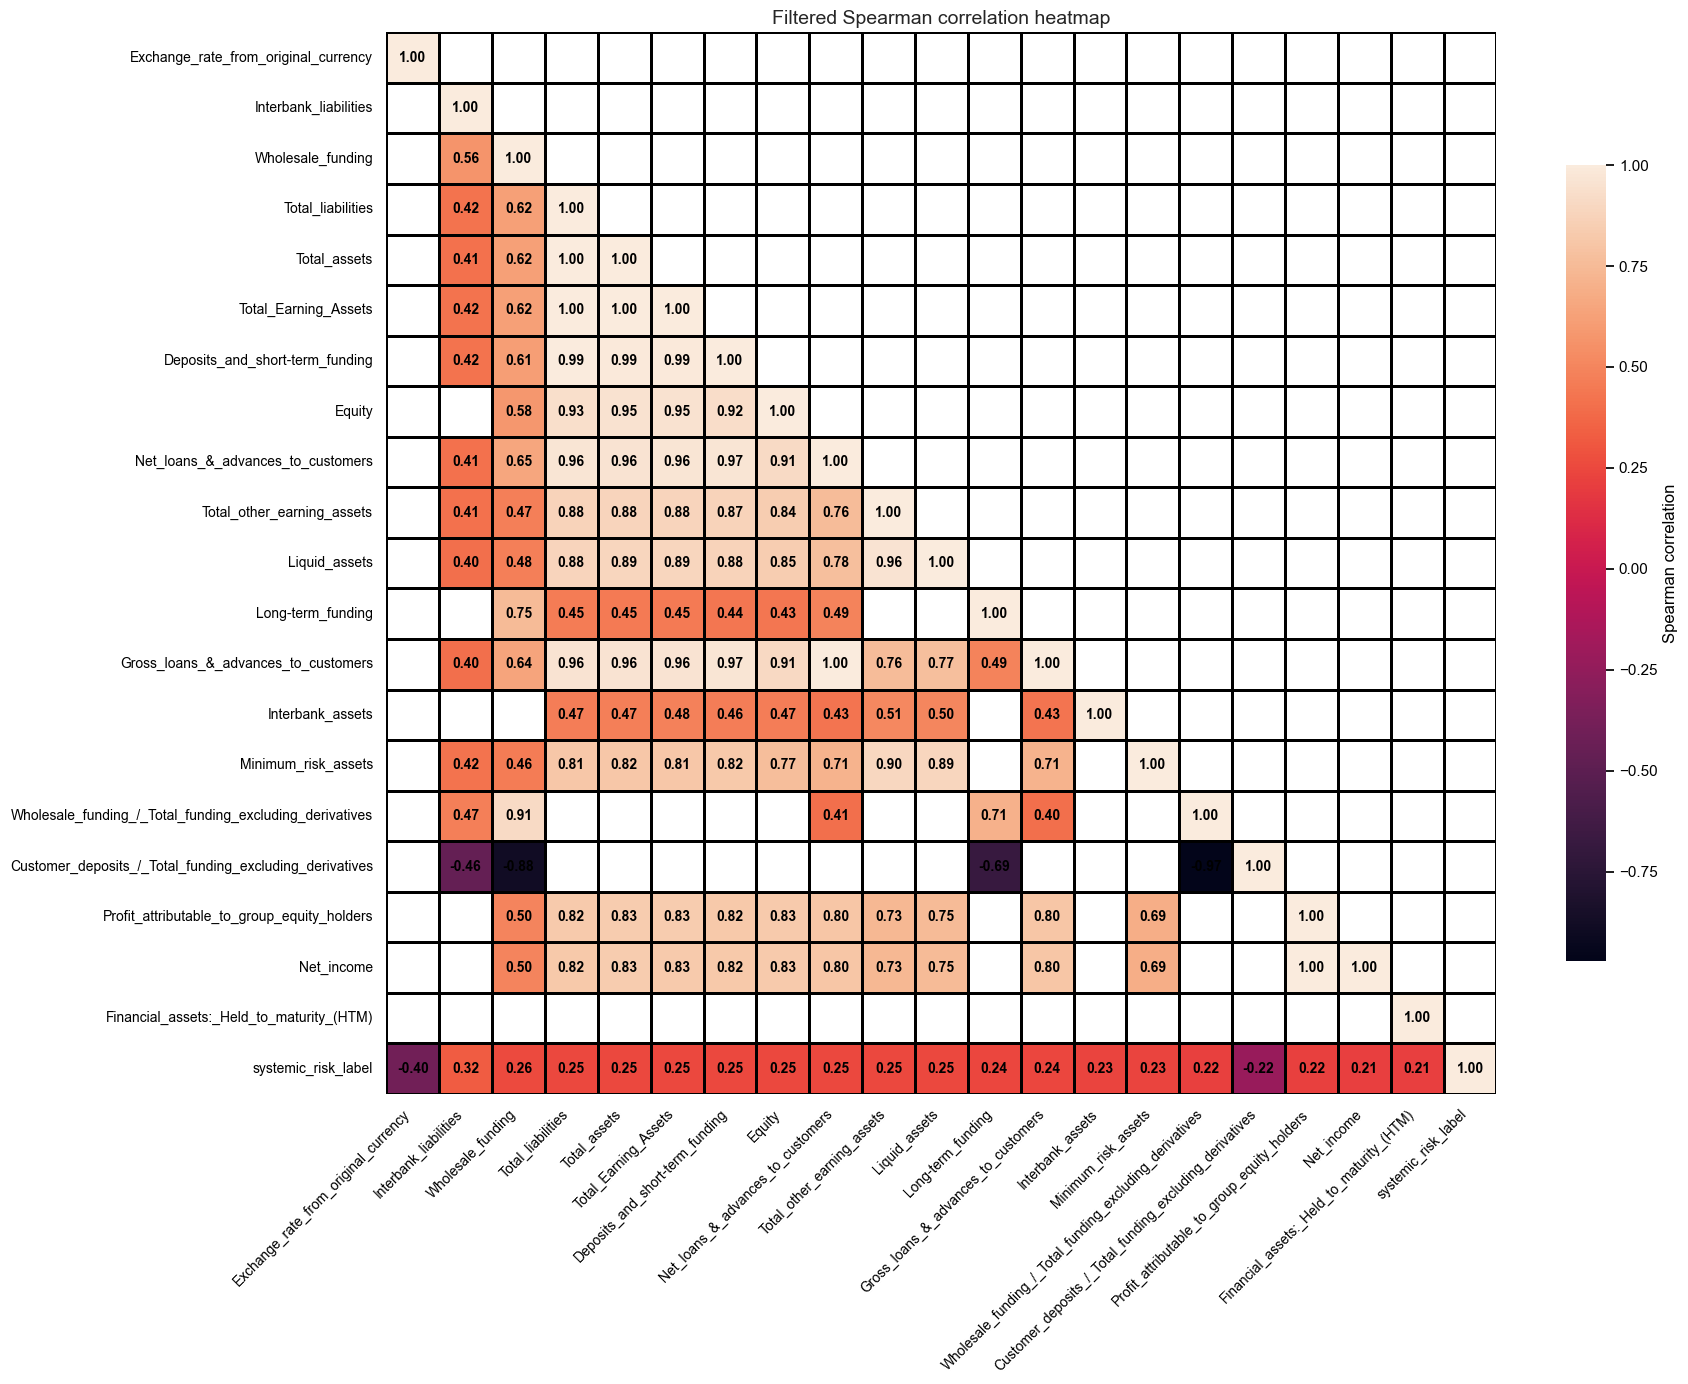

In [149]:

selected_corr_features = target_spearman.head(TOP_N_FEATURES).index.tolist()
selected_corr_cols = selected_corr_features + [TARGET_COL]
spearman_subset = spearman_corr.loc[selected_corr_cols, selected_corr_cols]

upper_triangle_mask = pd.DataFrame(
    np.triu(np.ones_like(spearman_subset, dtype=bool), k=1),
    index=spearman_subset.index,
    columns=spearman_subset.columns,
)
weak_corr_mask = spearman_subset.abs() < MIN_ABS_FEATURE_CORR_TO_SHOW

# Keep the target row and column visible even when values are below the threshold.
weak_corr_mask.loc[TARGET_COL, :] = False
weak_corr_mask.loc[:, TARGET_COL] = False

combined_mask = upper_triangle_mask | weak_corr_mask

plt.figure(figsize=(18, 14))
ax = sns.heatmap(
    spearman_subset,
    mask=combined_mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10, "weight": "bold", "color": "black"},
    linewidths=1.0,
    linecolor="black",
    cbar_kws={"label": "Spearman correlation", "shrink": 0.75},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title("Filtered Spearman correlation heatmap", fontsize=14)
plt.tight_layout()
plt.show()


In [150]:

# Same target-correlation check after removing the many target = 1 rows.
risk_tail_spearman = (
    risk_tail_df[normal_feature_cols + [TARGET_COL]]
    .corr(method="spearman", numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

risk_tail_spearman.head(20).to_frame("spearman_corr_with_target_without_ones")


,spearman_corr_with_target_without_ones
Interbank_liabilities,0.8204
Wholesale_funding,0.7236
Total_other_earning_assets,0.6720
Liquid_assets,0.6661
Interbank_assets,0.6631
Total_liabilities,0.6549
Total_assets,0.6540
Total_Earning_Assets,0.6431
Deposits_and_short-term_funding,0.6399
Equity,0.6014


## Main Insights

- The target is highly concentrated at 1. The median, 75th percentile, 90th percentile, and 95th percentile are all equal to 1.
- Rows with `systemic_risk_label > 1` are the important tail to inspect separately. This filtered view makes the rare higher-risk observations visible instead of hiding them inside the mass of ones.
- Target levels are fairly stable over time, but the higher average-risk periods include 2022Q1-2022Q3 and 2016Q1.
- Normal size and funding variables are most related to the target in the correlation checks. Examples include `Interbank_liabilities`, `Wholesale_funding`, `Total_assets`, `Total_liabilities`, `Equity`, and `Liquid_assets`.
- Pearson correlations are stronger than Spearman correlations for several size variables. This suggests that very large banks and outliers have a strong effect on linear relationships.
- `rank_next_quarter`, `srisk_ratio`, and `srisk_value` should stay separated from the normal feature set because they may contain future or target-related information.
